# 4. Embeddings sur les Avis d'Assurance

Ce notebook explore les représentations vectorielles de mots (word embeddings) appliquées à un corpus d'avis d'assurance.

In [1]:
import os
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from gensim.models import Word2Vec, LdaModel
from gensim import corpora
from nltk.tokenize import word_tokenize, sent_tokenize
from scipy.spatial.distance import cosine as sp_cosine
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorboard.plugins import projector
import faiss
from sentence_transformers import SentenceTransformer

from config import *

/Users/amaitre/venv_tf311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')

## 4.1 Chargement des données

In [3]:
df = pd.read_csv(DATA_CLEAN)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24100 entries, 0 to 24099
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24100 non-null  float64
 1   auteur            24099 non-null  str    
 2   avis              24100 non-null  str    
 3   assureur          24100 non-null  str    
 4   produit           24100 non-null  str    
 5   type              24100 non-null  str    
 6   date_publication  24100 non-null  str    
 7   date_exp          24100 non-null  str    
 8   avis_en           24099 non-null  str    
 9   avis_cor          0 non-null      float64
 10  avis_cor_en       0 non-null      float64
 11  avis_clean        24099 non-null  str    
 12  avis_taille       24100 non-null  int64  
 13  avis_clean_len    24100 non-null  int64  
 14  nb_mots           24100 non-null  int64  
dtypes: float64(3), int64(3), str(9)
memory usage: 23.5 MB


In [5]:
# Tokenize chaque review en phrases, puis chaque phrase en mots
df = df.dropna(subset=[CLEAN_COL])

tokenized_sentences = []
tokenized_words_per_review = []

for review in df[CLEAN_COL]:
    sentences = sent_tokenize(str(review).lower())
    words_in_review = []
    for sent in sentences:
        words = word_tokenize(sent)
        words = [w for w in words if w.isalpha()]
        if words:
            tokenized_sentences.append(words)
            words_in_review.extend(words)
    tokenized_words_per_review.append(words_in_review)

In [6]:
print(f'Total phrases tokenizer (training): {len(tokenized_sentences)}')
print(f'Example : {tokenized_sentences[0][:10]}')

Total phrases tokenizer (training): 24104
Example : ['personne', 'téléphoner', 'clair', 'sympathique', 'bien', 'expliquer', 'recommanderai', 'assurance', 'sans', 'hésitation']


## 4.2 Word2Vec avec Gensim

modèle **Skip-Gram** (`sg=1`)

In [7]:
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    epochs=10,
    sg=1
)

vocab_size = len(w2v_model.wv)
print(f'Taille du vocabulaire Word2Vec : {vocab_size} mots')
print(f'Dimension des vecteurs : {w2v_model.wv.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Taille du vocabulaire Word2Vec : 6790 mots
Dimension des vecteurs : 100


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [8]:
#test w2v_model
query_words = ['sinistre', 'remboursement', 'contrat', 'resilier', 'service']

for word in query_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f'{w} ({s:.3f})' for w, s in similar])
        print(f"Mots similaires à '{word}':")
        print(f'{similar_str}')
        print()

Mots similaires à 'sinistre':
incident (0.707), inimaginable (0.652), accrochag (0.650), accident (0.648), hic (0.641)

Mots similaires à 'remboursement':
remboursemer (0.758), orthodontie (0.659), consultation (0.658), dentaire (0.653), lentille (0.645)

Mots similaires à 'contrat':
déménage (0.655), rengager (0.650), exception (0.647), électroniquement (0.644), divorce (0.640)

Mots similaires à 'service':
cohérer (0.741), convien (0.729), acceuil (0.728), globalité (0.727), adhesion (0.711)



In [9]:
# Similarité cosine entre paires de mots
word_pairs = [
    ('assurance', 'contrat'),
    ('sinistre', 'accident'),
    ('prix', 'cher'),
    ('service', 'conseiller'),
    ('resilier', 'resiliation'),
]

print('Similarité cosine entre paires de mots (Word2Vec) :')
print(f'{"Mot 1":<15} {"Mot 2":<15} {"Similarité":<12}')
print('-' * 42)
for w1, w2 in word_pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        print(f'{w1:<15} {w2:<15} {sim:.4f}')
    else:
        missing = w1 if w1 not in w2v_model.wv else w2
        print(f'{w1:<15} {w2:<15} N/A ("{missing}" absent du vocabulaire)')

Similarité cosine entre paires de mots (Word2Vec) :
Mot 1           Mot 2           Similarité  
------------------------------------------
assurance       contrat         0.4866
sinistre        accident        0.6481
prix            cher            0.5875
service         conseiller      0.6014
resilier        resiliation     N/A ("resilier" absent du vocabulaire)


In [10]:
w2v_model.save('../models/word2vec.model')

## 4.3 Distances cosine et euclidienne

Comparaison de 10 paires de mots (liés et non liés) via deux métriques de distance.

In [11]:
# 10 paires : mélange de mots liés et non liés
word_pairs_dist = [
    ('assurance', 'contrat', 'lié'),
    ('sinistre', 'accident', 'lié'),
    ('prix', 'cher', 'lié'),
    ('service', 'conseiller', 'lié'),
    ('resilier', 'resiliation', 'lié'),
    ('assurance', 'cuisine', 'non lié'),
    ('sinistre', 'plaisir', 'non lié'),
    ('remboursement', 'voiture', 'non lié'),
    ('contrat', 'maison', 'non lié'),
    ('prix', 'maladie', 'non lié'),
]

results = []
for w1, w2, relation in word_pairs_dist:
    in_vocab = w1 in w2v_model.wv and w2 in w2v_model.wv
    if in_vocab:
        v1 = w2v_model.wv[w1]
        v2 = w2v_model.wv[w2]
        cos_sim = 1 - sp_cosine(v1, v2)
        cos_dist = sp_cosine(v1, v2)
        euc_dist = float(np.linalg.norm(v1 - v2))
        results.append((w1, w2, relation, f'{cos_sim:.4f}', f'{cos_dist:.4f}', f'{euc_dist:.4f}', 'oui'))
    else:
        missing = w1 if w1 not in w2v_model.wv else w2
        results.append((w1, w2, relation, 'N/A', 'N/A', 'N/A', f'non ("{missing}")'))

df_dist = pd.DataFrame(results, columns=['Mot 1', 'Mot 2', 'Relation', 'Sim. Cosine', 'Dist. Cosine', 'Dist. Eucl.',
                                         'Dans vocab'])

In [12]:
print('Distances entre paires de mots (Word2Vec 100d) :')
display(df_dist)

Distances entre paires de mots (Word2Vec 100d) :


,Mot 1,Mot 2,Relation,Sim. Cosine,Dist. Cosine,Dist. Eucl.,Dans vocab
0,assurance,contrat,lié,0.4866,0.5134,2.4562,oui
1,sinistre,accident,lié,0.6481,0.3519,2.5181,oui
2,prix,cher,lié,0.5875,0.4125,2.8247,oui
3,service,conseiller,lié,0.6014,0.3986,2.3199,oui
4,resilier,resiliation,lié,N/A,N/A,N/A,"non (""resilier"")"
5,assurance,cuisine,non lié,0.2241,0.7759,3.0157,oui
6,sinistre,plaisir,non lié,0.1784,0.8216,3.5536,oui
7,remboursement,voiture,non lié,0.1503,0.8497,4.1404,oui
8,contrat,maison,non lié,0.2220,0.7780,3.5404,oui
9,prix,maladie,non lié,0.2531,0.7469,4.2147,oui


## 4.4 Visualisation t-SNE 2D

In [13]:
vocab_counts = {word: w2v_model.wv.get_vecattr(word, 'count') for word in w2v_model.wv.index_to_key}
top_words = sorted(vocab_counts, key=vocab_counts.get, reverse=True)[:200]

In [14]:
vectors = np.array([w2v_model.wv[w] for w in top_words])
print(f'Shape des vecteurs pour t-SNE : {vectors.shape}')

Shape des vecteurs pour t-SNE : (200, 100)


In [15]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_coords = tsne.fit_transform(vectors)
print(f't-SNE terminé. Shape: {tsne_coords.shape}')

t-SNE terminé. Shape: (200, 2)


In [16]:
lda = LdaModel.load(str(LDA_MODELS_DIR))
lda_dict = corpora.Dictionary.load(str(DICTIONARIES_DIR))

In [17]:
categories = {
    label: [word for word, _ in lda.show_topic(topic_id, topn=30)]
    for topic_id, label in TOPIC_LABELS.items()
}

In [18]:
def get_category(word):
    for cat, words in categories.items():
        if word in words:
            return cat
    return 'Autre'

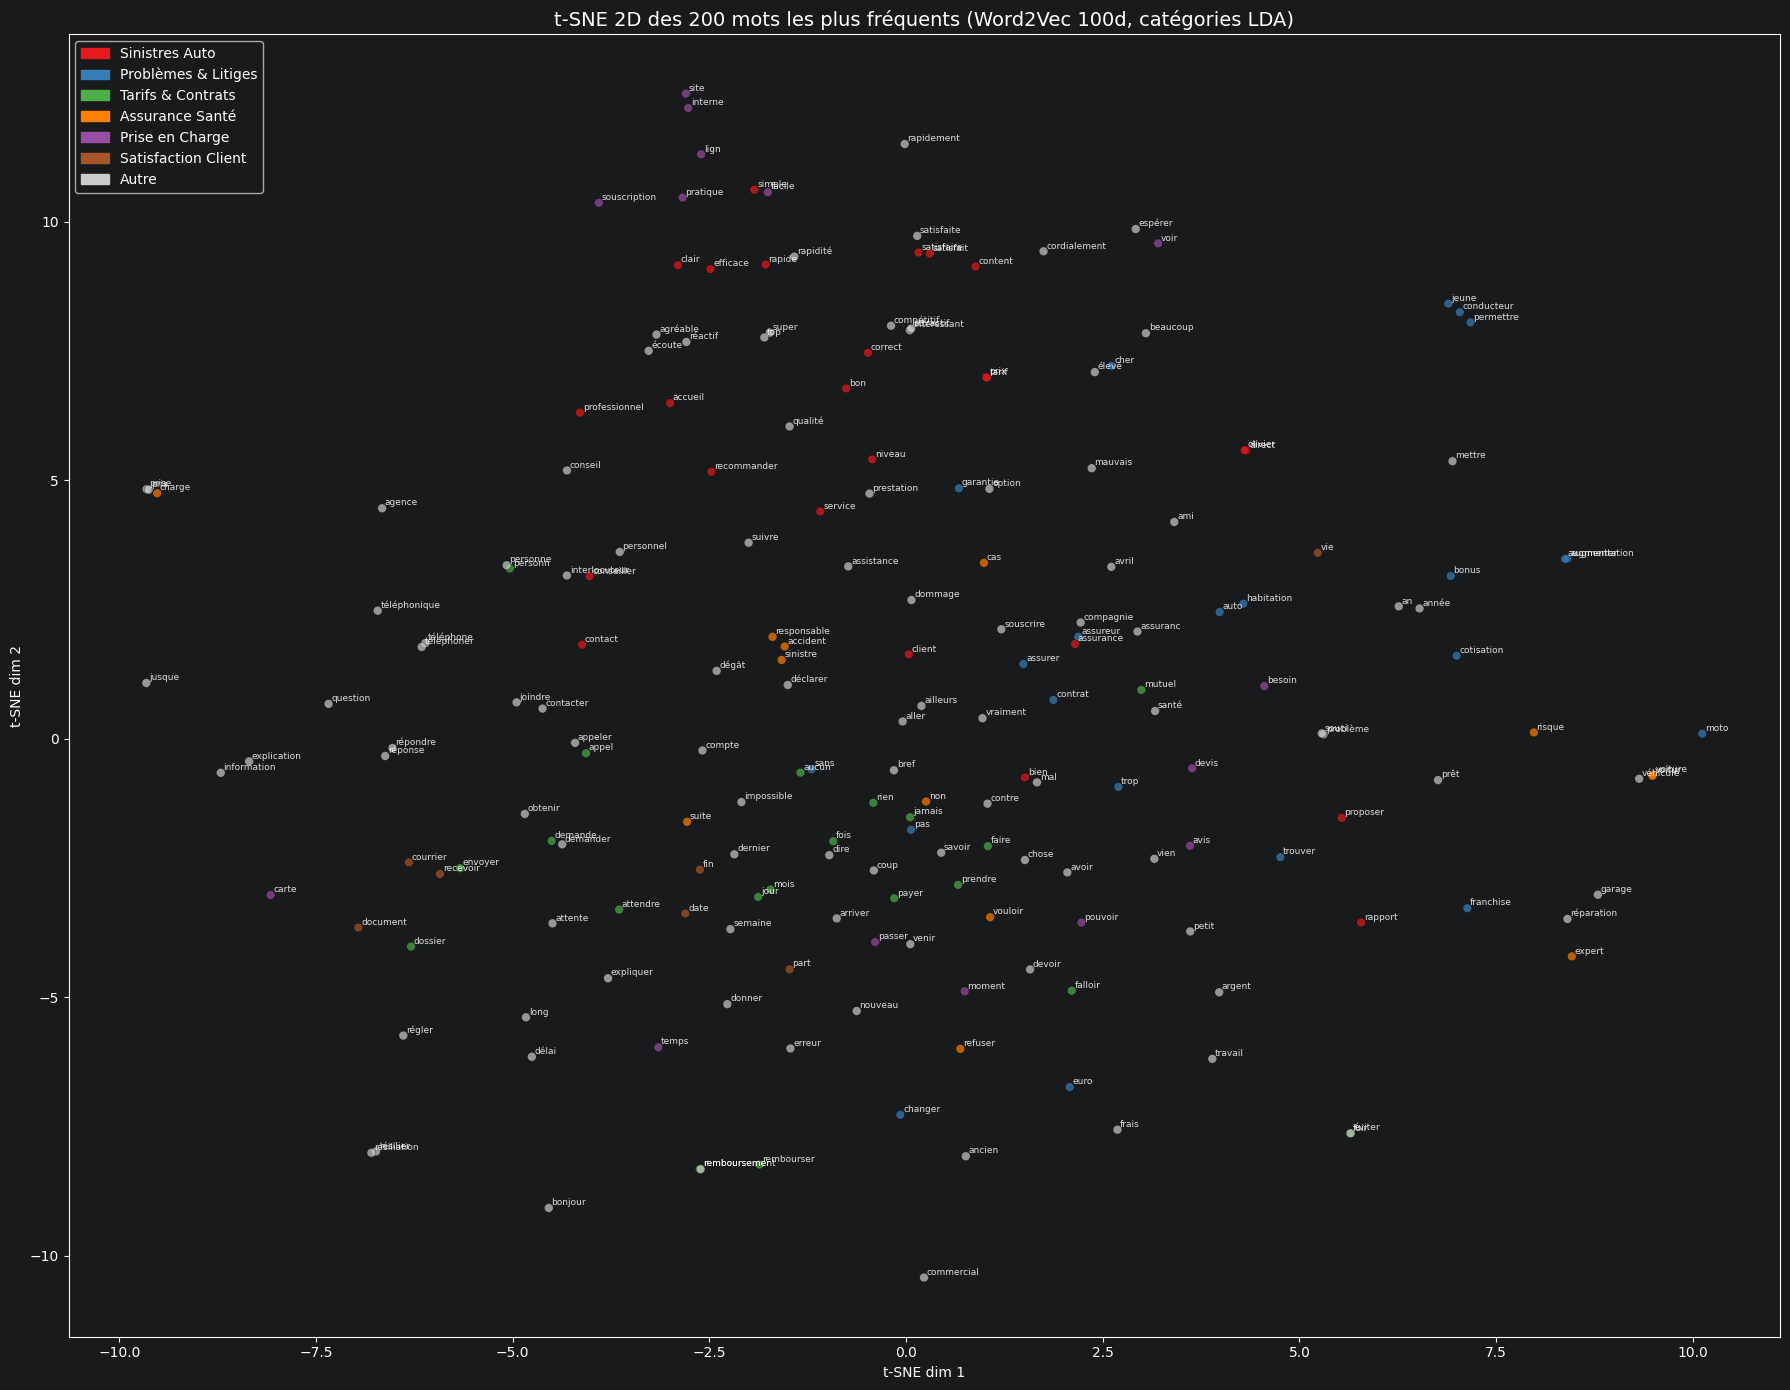

In [19]:
color_map = {
    'Sinistres Auto': '#e41a1c',
    'Problèmes & Litiges': '#377eb8',
    'Tarifs & Contrats': '#4daf4a',
    'Assurance Santé': '#ff7f00',
    'Prise en Charge': '#984ea3',
    'Satisfaction Client': '#a65628',
    'Autre': '#cccccc',
}

word_categories = [get_category(w) for w in top_words]
point_colors = [color_map[c] for c in word_categories]

fig, ax = plt.subplots(figsize=(18, 14))
ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=point_colors, alpha=0.7, s=40, linewidths=0.3, edgecolors='k')

for i, word in enumerate(top_words):
    ax.annotate(word, xy=(tsne_coords[i, 0], tsne_coords[i, 1]),
                fontsize=6.5, alpha=0.85, xytext=(2, 2), textcoords='offset points')

legend_patches = [mpatches.Patch(color=color_map[cat], label=cat) for cat in color_map]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10, framealpha=0.8)
ax.set_title('t-SNE 2D des 200 mots les plus fréquents (Word2Vec 100d, catégories LDA)', fontsize=14)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

## 4.5 Export TensorBoard Projector

Exportation des embeddings Word2Vec au format TSV pour TensorBoard Embedding Projector.

In [20]:
TENSORBOARD_DIR.mkdir(parents=True, exist_ok=True)

In [21]:
export_words = w2v_model.wv.index_to_key[:5000]

In [22]:
with open(VECTORS_PATH, 'w', encoding='utf-8') as fv:
    for word in export_words:
        vec = w2v_model.wv[word]
        fv.write('\t'.join(str(x) for x in vec) + '\n')
print(f'Vecteurs : {VECTORS_PATH}')

Vecteurs : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/tensorboard_logs/embeddings/vectors.tsv


In [23]:
with open(METADATA_PATH, 'w', encoding='utf-8') as fm:
    for word in export_words:
        fm.write(word + '\n')
print(f'Métadonnées : {METADATA_PATH}')
print(f'{len(export_words)} mots exportés.')

Métadonnées : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/tensorboard_logs/embeddings/metadata.tsv
5000 mots exportés.


In [24]:
emb_array = np.array([w2v_model.wv[w] for w in export_words], dtype=np.float32)
weights = tf.Variable(emb_array, trainable=False, name='word_embeddings')

2026-03-30 11:57:24.084781: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-30 11:57:24.084808: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-30 11:57:24.084812: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-30 11:57:24.084826: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-30 11:57:24.084834: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [25]:
ckpt = tf.train.Checkpoint(embedding=weights)
ckpt.save(os.path.join(LOG_DIR, 'embedding.ckpt'))

'/Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/tensorboard_logs/embedding.ckpt-1'

In [26]:
config = projector.ProjectorConfig()
embedding = config.embeddings.add()
embedding.tensor_name = 'embedding/.ATTRIBUTES/VARIABLE_VALUE'
embedding.metadata_path = 'embeddings/metadata.tsv'
projector.visualize_embeddings(LOG_DIR, config)

## 4.6 Semantic Search avec FAISS (bonus)

Construction d'un index FAISS `IndexFlatL2` sur les vecteurs Word2Vec pour une recherche par similarité rapide.

In [27]:
all_words = w2v_model.wv.index_to_key
all_vecs = np.array([w2v_model.wv[w] for w in all_words], dtype=np.float32)
dim = all_vecs.shape[1]

In [28]:
index_word = faiss.IndexFlatL2(dim)
index_word.add(all_vecs)
print(f'Index FAISS (Word2Vec) : {index_word.ntotal} vecteurs, dim={dim}')

Index FAISS (Word2Vec) : 6790 vecteurs, dim=100


In [29]:
def semantic_search(query_word: str, top_k: int = 10):
    if query_word not in w2v_model.wv:
        print(f"'{query_word}' absent du vocabulaire.")
        return []
    query_vec = np.array([w2v_model.wv[query_word]], dtype=np.float32)
    distances, indices = index_word.search(query_vec, top_k + 1)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        word = all_words[idx]
        if word != query_word:
            results.append((word, float(dist)))
    return results[:top_k]

In [30]:
test_queries = ['cher', 'conseiller', 'sinistre', 'resilier']
for q in test_queries:
    results = semantic_search(q, top_k=10)
    if results:
        res_str = ', '.join([f'{w} ({d:.3f})' for w, d in results])
        print(f"\nFAISS recherche '{q}' : {res_str}")


FAISS recherche 'cher' : élève (4.891), onéreux (5.245), compar (5.302), cheval (5.390), traditionnel (5.477), goût (5.530), franchiser (5.627), dorénavant (5.649), comparativement (5.678), viell (5.754)

FAISS recherche 'conseiller' : réactive (2.829), teleconseiller (2.865), diable (2.936), compréhensive (3.011), arrangeant (3.023), bienveiller (3.027), séraphin (3.029), veiller (3.036), accueillit (3.039), téléconseiller (3.048)

FAISS recherche 'sinistre' : inimaginable (4.363), hic (4.468), accrochag (4.548), déplorer (4.683), ruse (4.708), suivit (4.766), princip (4.768), classe (4.831), suppose (4.841), partirai (4.843)
'resilier' absent du vocabulaire.


## 4.7 Semantic Search avec Sentence Transformers (bonus)

Encodage des avis avec `all-MiniLM-L6-v2` et recherche sémantique sur les phrases.

In [31]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21816.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [32]:
sample_size = min(1000, len(df))
sample_reviews = df[CLEAN_COL].sample(sample_size, random_state=42).tolist()
sample_reviews = [str(r) for r in sample_reviews]

In [33]:
print(f'Encodage de {sample_size} avis...')
sentence_embeddings = sbert_model.encode(
    sample_reviews,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f'Shape embeddings : {sentence_embeddings.shape}')

Encodage de 1000 avis...


Batches: 100%|██████████| 16/16 [00:01<00:00, 13.16it/s]

Shape embeddings : (1000, 384)


In [34]:
sbert_dim = sentence_embeddings.shape[1]
emb_norm = sentence_embeddings.copy().astype(np.float32)
faiss.normalize_L2(emb_norm)
sbert_index = faiss.IndexFlatIP(sbert_dim)
sbert_index.add(emb_norm)
print(f'Index FAISS (SBERT) : {sbert_index.ntotal} vecteurs, dim={sbert_dim}')

Index FAISS (SBERT) : 1000 vecteurs, dim=384


In [35]:
def search_reviews(query: str, top_k: int = 5):
    q_emb = sbert_model.encode([query], convert_to_numpy=True).astype(np.float32)
    faiss.normalize_L2(q_emb)
    scores, indices = sbert_index.search(q_emb, top_k)
    print(f"\n=== Recherche : '{query}' ===")
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), 1):
        review_text = sample_reviews[idx][:120]
        print(f'  [{rank}] score={score:.4f} | {review_text}...')

In [36]:
test_queries_sbert = [
    'mon sinistre a été refusé sans explication',
    'excellent service client très réactif',
    'trop cher pour les garanties proposées',
    'impossible de résilier mon contrat en ligne',
    'attente interminable pour un remboursement',
]
for q in test_queries_sbert:
    search_reviews(q, top_k=5)


=== Recherche : 'mon sinistre a été refusé sans explication' ===
  [1] score=0.6146 | an aucun sinistre sinistre galérer sans nom briller incompétence inutilité complet parfaire avoir besoin rien...
  [2] score=0.5581 | impossible joindre quelque rembourser sinistre résilier année choisirai cher capable mener bien dossier sinistre pourtan...
  [3] score=0.5419 | cotisation passer euro sans aucun explication bien entendre sans sinistre assurance période difficile pas augmenter tari...
  [4] score=0.5348 | an assurance atout venir recevoir courrier recommander voir trop sinistre an sinistre maximum totaliter an voir bizarre ...
  [5] score=0.5256 | assurer mois aucun sinistre souscrit contrat formule tiers intégral sans franchise convenir bien véhicule an souscriptio...

=== Recherche : 'excellent service client très réactif' ===
  [1] score=0.6491 | service sinistre réactif service client proposer tarif correspondre besoin satisfaisant recommander assurance...
  [2] score=0.6160 | bon 

In [37]:
faiss.write_index(sbert_index, str(FAISS_INDEX_DIR))
np.save(str(SENTENCE_EMBEDDINGS_DIR), sentence_embeddings)

**Lancer TensorBoard :**
```bash
tensorboard --logdir=../models/tensorboard_logs
```